In [ ]:
import qiskit
import qiskit_algorithms
import qiskit_optimization

import qiskit_aer
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2
from qiskit.primitives import Sampler
from qiskit_algorithms import QAOA, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization.algorithms import MinimumEigenOptimizer

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams["figure.dpi"] = 1000
mpl.rcParams["savefig.dpi"] = 1000

import math
import contextlib
import io
import os

import sys
import os
# Add parent directory to path to import max_k_cut
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), '../..')))

from max_k_cut import (
    docplex_BQO, docplex_RBQO, docplex_QUBO, docplex_RQUBO,
    tight_qubo_penalty, tight_rqubo_penalty, naive_qubo_penalty, naive_rqubo_penalty,
    interpolated_qubo_penalty, interpolated_rqubo_penalty,
    generate_graph, plot_graph, feasibility_filter, expected_value
)
from max_k_cut.qaoa import run_qaoa_extract_samples
from scripts.plot_histogram import plot_qaoa_histogram

# from qiskit_algorithms.utils import algorithm_globals
# algorithm_globals.random_seed = 123

import warnings
# Suppress specific DeprecationWarning
warnings.filterwarnings('ignore', category=DeprecationWarning)

print("qiskit version:",qiskit.__version__)
print("qiskit aer version:",qiskit_aer.__version__)
print("qiskit algorithms version:",qiskit_algorithms.__version__)
print("qiskit optimization version:",qiskit_optimization.__version__)

qiskit version: 1.3.2
qiskit aer version: 0.15.1
qiskit algorithms version: 0.3.1
qiskit optimization version: 0.6.1


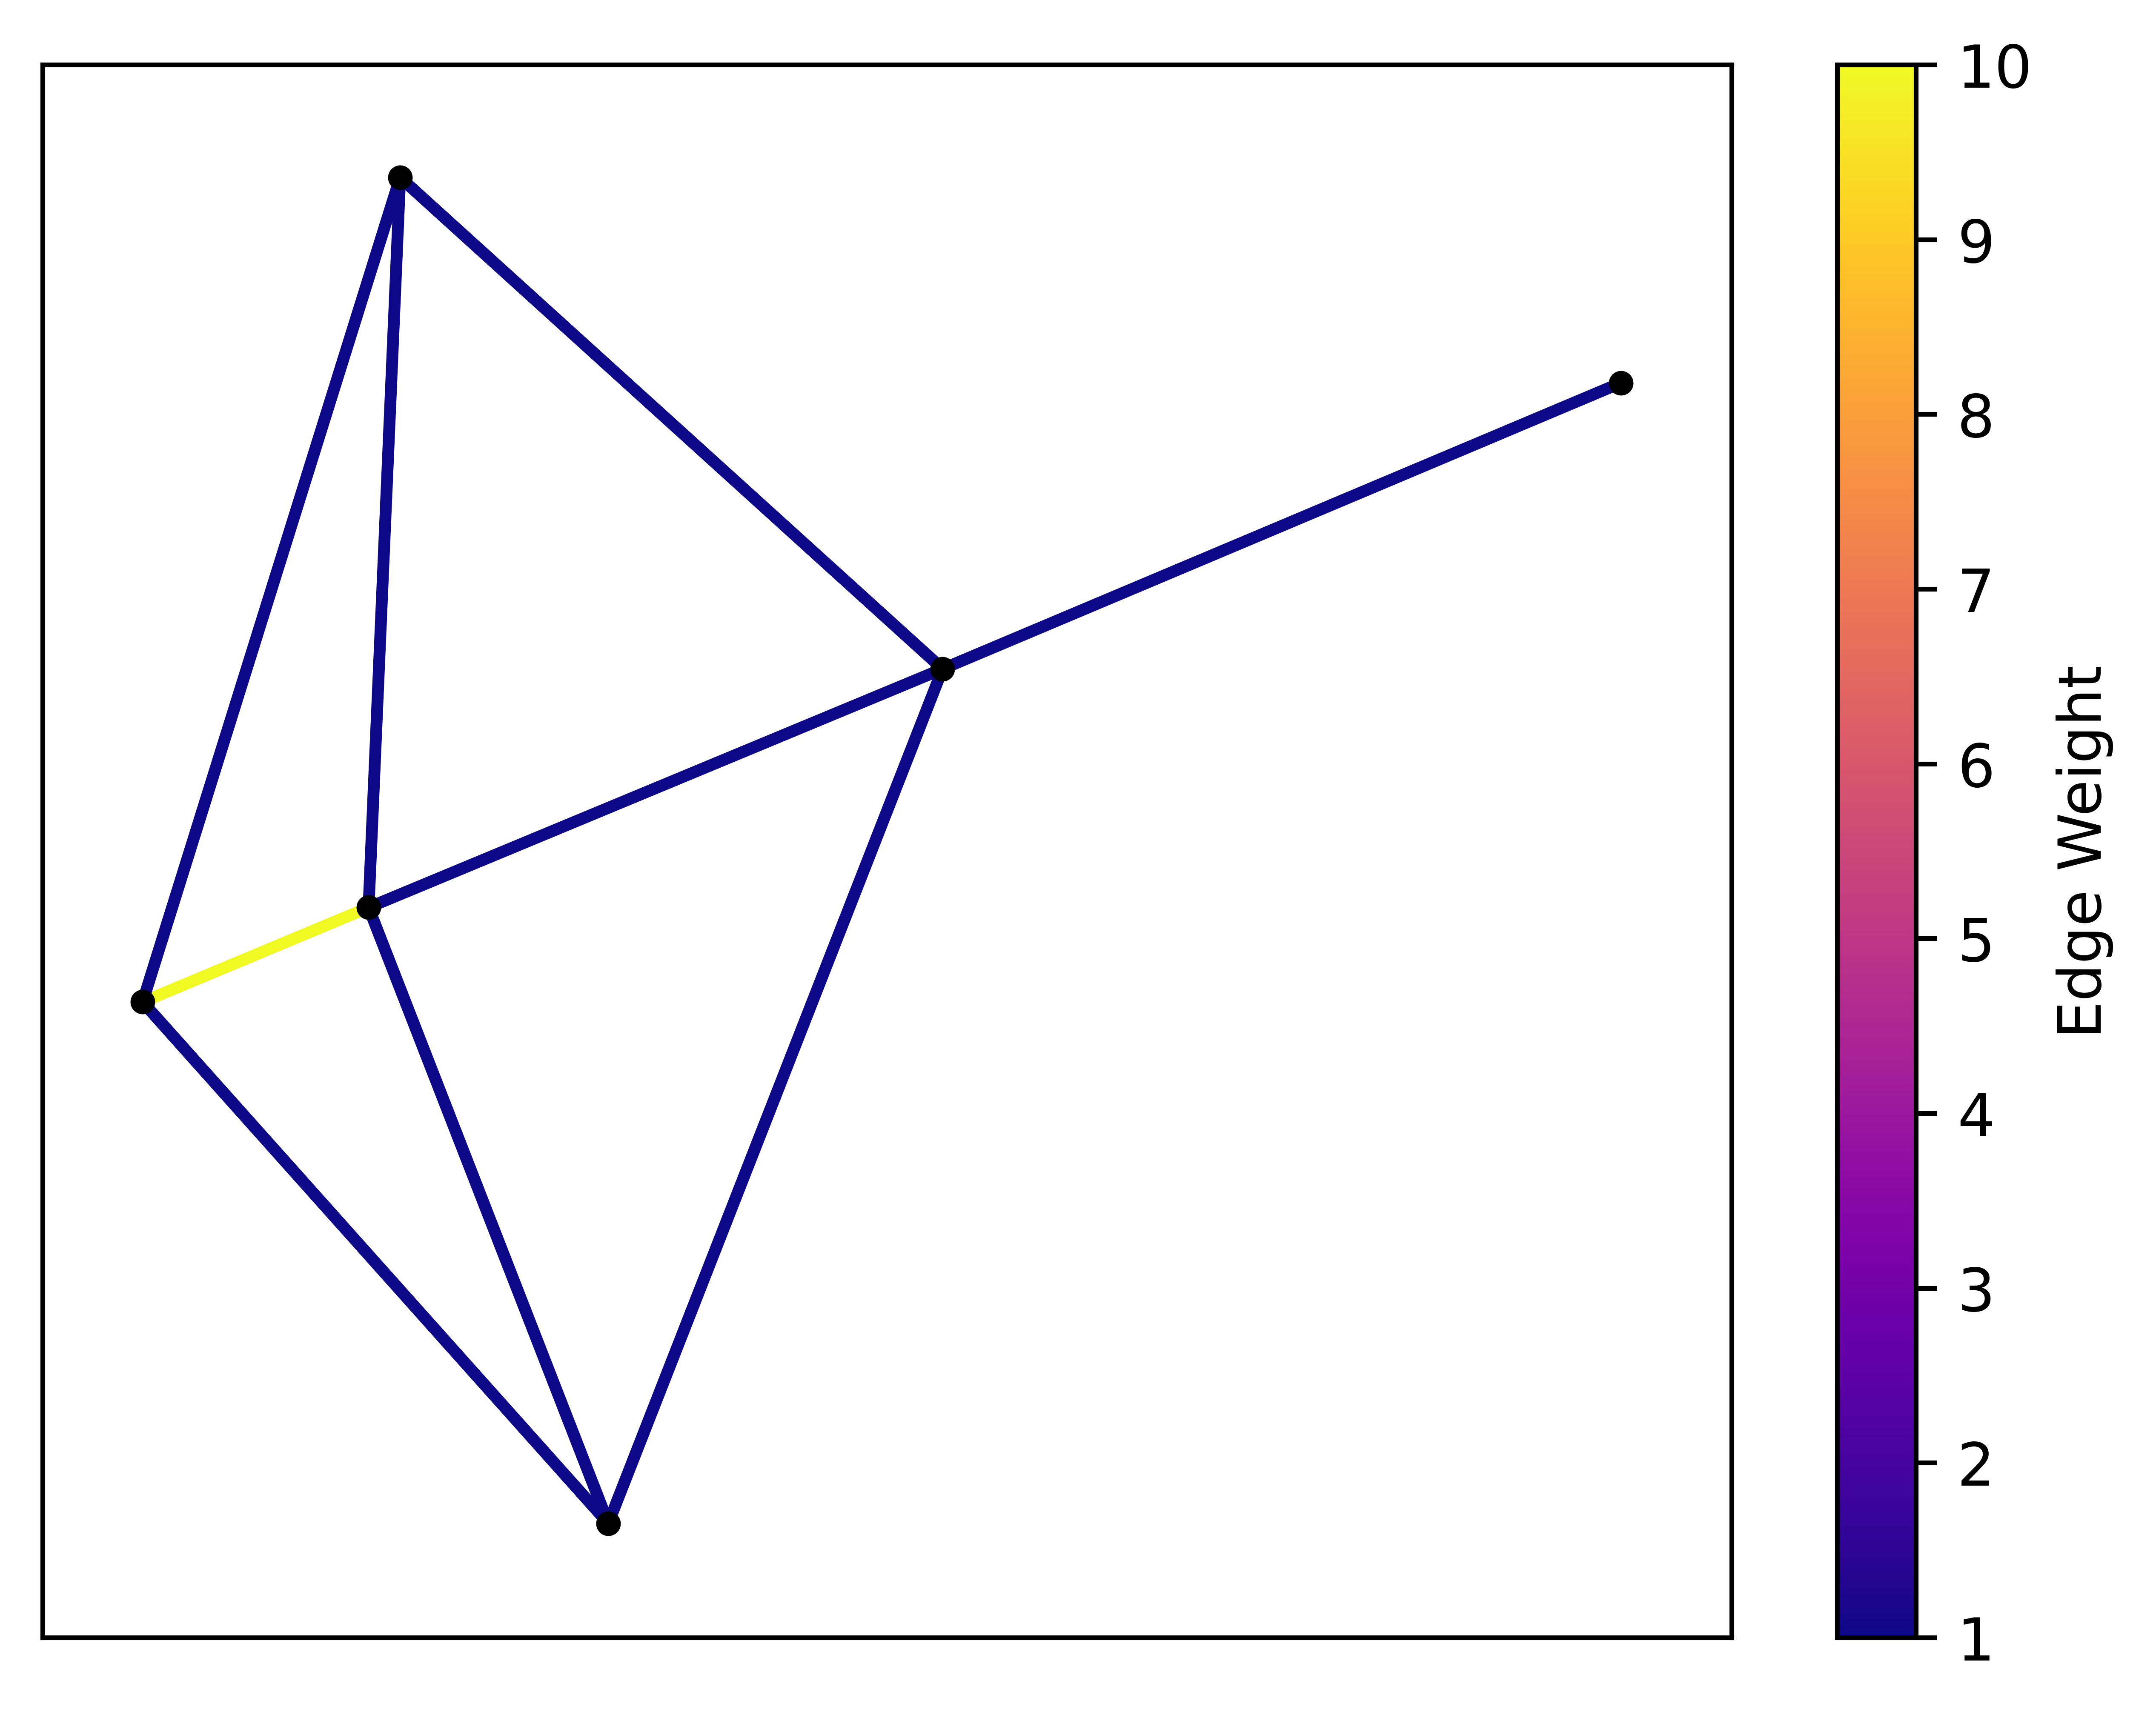

EdgeDataView([(0, 1, {'weight': 1}), (0, 2, {'weight': 1}), (0, 4, {'weight': 1}), (0, 5, {'weight': 1}), (1, 2, {'weight': 1}), (1, 3, {'weight': 1}), (2, 3, {'weight': 10}), (2, 5, {'weight': 1}), (3, 5, {'weight': 1})])

In [5]:
def add_a_weighted_edge(graph, weight):

    # Get all edge data
    edges = list(graph.edges(data=True))

    # Extract edge weights and check if graph is weighted
    weights = [d['weight'] for (_, _, d) in edges]

    # pick a random edge to add weight to
    random_edge = np.random.choice(len(weights))

    # Check if graph is weighted
    (u, v, _) = edges[random_edge]
    graph.edges[u, v]['weight'] = weight

    # Add weight
    # weights[random_edge] = weight

    return graph


test_graph = generate_graph(6, 0.5, False)
test_graph_weighted = add_a_weighted_edge(test_graph, 10)
plot_graph(test_graph)
test_graph.edges(data=True)

In [6]:
# parameters
# Get the noise model and coupling map from the backend
backend = FakeAlmadenV2()
backend = AerSimulator.from_backend(backend)
sampler = Sampler()
cvar_alpha = 1 # alpha for CVaR aggregation in (0,1], 1 for full distribution, 0 for only the best solution
shots = 10000/cvar_alpha
sampler.set_options(shots=shots, backend=backend)
optimizer = COBYLA()
reps = 3
initial_point = np.random.rand(2 * reps) * np.pi / 2 # initial point for the optimizer

# solvers
qaoa = QAOA(
    sampler=sampler, 
    optimizer=optimizer, 
    reps=reps, 
    initial_point=initial_point,
    aggregation=cvar_alpha
    )

np_solver = NumPyMinimumEigensolver() # exact classical solver
# create minimum eigen optimizer based on solver used
qaoa_optimizer = MinimumEigenOptimizer(qaoa)
np_optimizer = MinimumEigenOptimizer(np_solver)

# Experiment parameters
K = 3
num_nodes = 6
edge_probability = 0.5
weighted = False
weight_range = 1

In [7]:
penalty_list = np.linspace(0, 1, 6)
num_graphs = 20

QUBO_EXP_VALS     = np.zeros((num_graphs, len(penalty_list))) 
QUBO_FEASIBILITY  = np.zeros((num_graphs, len(penalty_list)))
RQUBO_EXP_VALS    = np.zeros((num_graphs, len(penalty_list)))
RQUBO_FEASIBILITY = np.zeros((num_graphs, len(penalty_list)))

for graph in range(num_graphs):
    # generate random graph
    G = generate_graph(num_nodes, edge_probability, weighted, weight_range)
    # add a random edge with weight 100
    G = add_a_weighted_edge(G, 10)
    
    for pen_index, pen in enumerate(penalty_list):
        # Create docplex models
        dp_qubo_interp = docplex_QUBO(G, K, interpolated_qubo_penalty(G, K, pen), "Max-K-Cut")
        dp_rqubo_interp = docplex_RQUBO(G, K, interpolated_rqubo_penalty(G, K, pen), "Max-K-Cut")

        with contextlib.redirect_stdout(io.StringIO()):
            # Run QAOA
            results_dict = run_qaoa_extract_samples(
                [dp_qubo_interp, dp_rqubo_interp],
                ["QUBO (Interpolated)", "RQUBO (Interpolated)"],
                optimizer=qaoa_optimizer
            )
            
            # Retrieve the raw samples
            samples_qubo = results_dict["QUBO (Interpolated)"]["samples"]
            samples_rqubo = results_dict["RQUBO (Interpolated)"]["samples"]
            
            # Filter the samples and get the feasibility probability.
            filtered_samples_qubo, feas_prob_qubo = feasibility_filter(G, K, samples_qubo, "QUBO (Interpolated)")
            filtered_samples_rqubo, feas_prob_rqubo = feasibility_filter(G, K, samples_rqubo, "RQUBO (Interpolated)")

            # Calculate the expected value of the objective function.
            exp_val_qubo = expected_value(filtered_samples_qubo)
            exp_val_rqubo = expected_value(filtered_samples_rqubo)

            # Store the results
            QUBO_EXP_VALS[graph, pen_index] = exp_val_qubo
            QUBO_FEASIBILITY[graph, pen_index] = feas_prob_qubo

            RQUBO_EXP_VALS[graph, pen_index] = exp_val_rqubo
            RQUBO_FEASIBILITY[graph, pen_index] = feas_prob_rqubo
        
        # Print the results
        print(f"Graph {graph+1}/{num_graphs}, Penalty {pen:.2f}:")
        print(f"  QUBO Expected Value: {exp_val_qubo:.4f}, Feasibility Probability: {feas_prob_qubo:.4f}")
        print(f"  RQUBO Expected Value: {exp_val_rqubo:.4f}, Feasibility Probability: {feas_prob_rqubo:.4f}")

# save results
os.makedirs("Data", exist_ok=True)
np.savez(
    os.path.join("Data", "QUBO_RQUBO_Noisy_Results_P3_random_init.npz"),
    QUBO_EXP_VALS=QUBO_EXP_VALS,
    QUBO_FEASIBILITY=QUBO_FEASIBILITY,
    RQUBO_EXP_VALS=RQUBO_EXP_VALS,
    RQUBO_FEASIBILITY=RQUBO_FEASIBILITY
)

Graph 1/20, Penalty 0.00:
  QUBO Expected Value: 0.6979, Feasibility Probability: 0.0047
  RQUBO Expected Value: 0.6434, Feasibility Probability: 0.2825
Graph 1/20, Penalty 0.20:
  QUBO Expected Value: 0.5847, Feasibility Probability: 0.0048
  RQUBO Expected Value: 0.8065, Feasibility Probability: 0.2373
Graph 1/20, Penalty 0.40:
  QUBO Expected Value: 0.6528, Feasibility Probability: 0.0082
  RQUBO Expected Value: 0.6942, Feasibility Probability: 0.2215
Graph 1/20, Penalty 0.60:
  QUBO Expected Value: 0.6357, Feasibility Probability: 0.0071
  RQUBO Expected Value: 0.7067, Feasibility Probability: 0.2523
Graph 1/20, Penalty 0.80:
  QUBO Expected Value: 0.5184, Feasibility Probability: 0.0085
  RQUBO Expected Value: 0.6329, Feasibility Probability: 0.5524
Graph 1/20, Penalty 1.00:
  QUBO Expected Value: 0.5619, Feasibility Probability: 0.0098
  RQUBO Expected Value: 0.6159, Feasibility Probability: 0.3526
Graph 2/20, Penalty 0.00:
  QUBO Expected Value: 0.7654, Feasibility Probability: 